1. fetch data finance with yfinance then count the bullish and bearish candlestick
2. calculate the payoff matrix with as well as @Latex/PakHeru_Presentasi4/Adv_Gemini_plan until.md we get the probability of each state as well as @Latex/PakGagus_Presentasi3/rencana_presentasi_analisis_numerik.md
3. fetch calculated value of payoff to calculate bias
4. construct the density matrix to get the value of von neumann entropy as interaction (J_ij)
5. fetch the bias and interaction value to hamiltonian ising 
6. use vqe algorithm to get the ground stat with ansatz efficientSU2
7. rebalance the algorithm in 5 year from 2021 until 2026

In [53]:
import yfinance as yf
import pandas as pd

# Daftar saham yang akan diambil datanya
tickers = ['BBCA.JK', 'TPIA.JK', 'ASII.JK', 'TLKM.JK']
start_date = '2025-01-06'
interval = '1d'

# Dictionary untuk menyimpan hasil perhitungan
candlestick_counts = {}

print(f"Fetching 100 days of data starting from {start_date} and counting candlesticks...\n")

for ticker in tickers:
    # Mengambil data historis mulai dari tanggal spesifik
    df = yf.download(ticker, start=start_date, interval=interval, progress=False)
    
    if df.empty:
        print(f"No data found for {ticker}")
        continue
    
    # Membatasi data menjadi 100 baris pertama sejak start_date
    df = df.head(100)
    
    # Menangani MultiIndex columns jika yfinance versi terbaru
    if isinstance(df.columns, pd.MultiIndex):
        open_price = df['Open'][ticker]
        close_price = df['Close'][ticker]
    else:
        open_price = df['Open']
        close_price = df['Close']
        
    # Perhitungan Candlestick
    bullish_count = int((close_price > open_price).sum())
    bearish_count = int((close_price < open_price).sum())
    neutral_count = int((close_price == open_price).sum())
    
    candlestick_counts[ticker] = {
        'Bullish': bullish_count,
        'Bearish': bearish_count,
        'Neutral': neutral_count,
        'Total Data': len(df)
    }
    
    print(f"[{ticker}]")
    print(f"  Bullish : {bullish_count}")
    print(f"  Bearish : {bearish_count}")
    print(f"  Neutral : {neutral_count}")
    print(f"  Total   : {len(df)}\n")

# Menampilkan rekap dalam bentuk DataFrame
summary_df = pd.DataFrame(candlestick_counts).T
summary_df

Fetching 100 days of data starting from 2025-01-06 and counting candlesticks...

[BBCA.JK]
  Bullish : 37
  Bearish : 51
  Neutral : 12
  Total   : 100

[TPIA.JK]
  Bullish : 49
  Bearish : 47
  Neutral : 4
  Total   : 100

[ASII.JK]
  Bullish : 42
  Bearish : 53
  Neutral : 5
  Total   : 100

[TLKM.JK]
  Bullish : 38
  Bearish : 51
  Neutral : 11
  Total   : 100



,Bullish,Bearish,Neutral,Total Data
BBCA.JK,37,51,12,100
TPIA.JK,49,47,4,100
ASII.JK,42,53,5,100
TLKM.JK,38,51,11,100


### Contoh Kalkulasi Manual: Payoff & Probabilitas (Metode Markowitz)

Misalkan kita mengamati 100 hari riwayat perdagangan untuk pasangan saham **Leader (BBCA)** dan **Follower (ASII)**.

#### 1. Parameter Pasar (Endogenous Risk Aversion)
Misalkan dari seluruh data historis bursa didapatkan:
- Rata-rata return pasar ($\mu_{avg}$) = `0.001` (0.1%)
- Rata-rata volatilitas pasar ($\sigma_{avg}$) = `0.015` (1.5%)
- Penghitungan $\lambda_{\text{market}}$:
  $$ \lambda = \frac{1}{1 + e^{\left(\frac{0.001}{0.015}\right)}} = \frac{1}{1 + e^{0.0667}} = \frac{1}{1 + 1.0689} \approx 0.4833 $$

#### 2. Perhitungan pada State $|00\rangle$ (Keduanya Sama-Sama Naik, $R_t > 0$)
Misalkan mereka naik secara bersamaan di hari yang sama sebanyak **45 hari** ($n_{00} = 45$).
- **Probabilitas ($P_{00}$)**: $\frac{n_{00}}{n_{total}} = \frac{45}{100} = 0.45$
- **Amplitudo Kuantum ($a_{00}$)**: $\sqrt{P_{00}} = \sqrt{0.45} \approx 0.6708$

#### 3. Perhitungan Utilitas Markowitz (Payoff) pada State $|00\rangle$
Misalkan jika kita ambil subset 45 hari di mana KEDUANYA NAIK tersebut, kita dapati:
- Rata-rata return harian BBCA $\mu_L^{(00)}$ = `0.010`
- Std dev return BBCA $\sigma_L^{(00)}$ = `0.005`
- Rata-rata return harian ASII $\mu_F^{(00)}$ = `0.012`
- Std dev return ASII $\sigma_F^{(00)}$ = `0.008`

**Maka Nilai Payoff BBCA (Leader) di Matriks (Baris 0, Kolom 0):**
$$ U_L^{(00)} = (1 - \lambda) \cdot \mu_L^{(00)} - \lambda \cdot \sigma_L^{(00)} $$
$$ U_L^{(00)} = (1 - 0.4833) \cdot 0.010 - 0.4833 \cdot 0.005 $$
$$ U_L^{(00)} = 0.005167 - 0.002416 = 0.002751 $$

**Sedangkan Nilai Payoff ASII (Follower) di Matriks (Baris 0, Kolom 0):**
$$ U_F^{(00)} = (1 - \lambda) \cdot \mu_F^{(00)} - \lambda \cdot \sigma_F^{(00)} $$
$$ U_F^{(00)} = (0.5167 \cdot 0.012) - (0.4833 \cdot 0.008) = 0.006200 - 0.003866 = 0.002334 $$

#### 4. Iterasi Selanjutnya (Penempatan di Matriks 2x2)
Proses (Frekuensi $\rightarrow$ $P_{ij}$ $\rightarrow$ Amplitudo Kuantum $a_{ij}$ $\rightarrow$ Nilai Subset $\mu, \sigma$ $\rightarrow$ $U_L, U_F$) ini kemudian diulangi pada:
- State $|01\rangle$: BBCA Naik, ASII Turun
- State $|10\rangle$: BBCA Turun, ASII Naik
- State $|11\rangle$: Keduanya Sama-Sama Turun

Sehingga menghasilkan secara utuh `Payoff_L` (Leader), `Payoff_F` (Follower), `Probabilities`, dan `Quantum_Coeffs`.


---

### Konstruksi Fungsi Gelombang dan Matriks Payoff

Berdasarkan metodologi **Markowitz $\times$ Game Theory (Risk Aversion Endogen)** dan **Econophysics Kuantum**, berikut adalah langkah-langkah formulasi dari data historis hingga mendapatkan fungsi gelombang $|\psi\rangle$.

#### 1. Perhitungan Return dan Penentuan State
Pertama, kita menghitung *Daily Log Return* ($R_t$) untuk mengidentifikasi pergerakan harga harian.
$$ R_t = \ln\left(\frac{P_t}{P_{t-1}}\right) $$

Setiap hari perdagangan kemudian didiskritisasi ke dalam dua *state* kuantum:
- **Naik ($|0\rangle$)**: Jika $R_t > 0$
- **Turun ($|1\rangle$)**: Jika $R_t \le 0$

#### 2. Risk Aversion Endogen ($\lambda_{\text{market}}$)
Alih-alih berasumsi menggunakan angka statis, kecenderungan penghindaran risiko (risk aversion) pasar dihitung berdasarkan volatilitas agregat:
$$ \lambda_{\text{market}} = \frac{1}{1 + e^{\left(\frac{\mu_{avg}}{\sigma_{avg}}\right)}} $$
- $\mu_{avg}$: Rata-rata *return* seluruh aset dalam pasar/portofolio.
- $\sigma_{avg}$: Rata-rata volatilitas (standar deviasi) seluruh aset.

#### 3. Konstruksi Matriks Payoff (Utilitas Markowitz)
Misalkan kita mengamati dua aset: **Leader ($L$)** dan **Follower ($F$)**. Kita menghitung utilitas objektif Markowitz untuk masing-masing aset berdasarkan subset waktu berlakunya state gabungan $|ij\rangle$ (misal: Leader naik, Follower turun).

Fungsi utilitas untuk aset $k \in \{L, F\}$ pada state $|ij\rangle$ adalah:
$$ U_k^{(ij)} = (1 - \lambda_{\text{market}}) \cdot \mu_{k}^{(ij)} - \lambda_{\text{market}} \cdot \sigma_{k}^{(ij)} $$
- $\mu_{k}^{(ij)}$: Rata-rata return harian aset $k$ HANYA pada hari-hari di mana state $|ij\rangle$ terjadi.
- $\sigma_{k}^{(ij)}$: Standar deviasi return harian aset $k$ pada hari-hari tersebut.

Matriks Payoff untuk pasangan $(L, F)$ kemudian dapat divisualisasikan sebagai tabel interaksi (Game Theory):
| L \ F | $\ket{0}_F$ (Up) | $\ket{1}_F$ (Down) |
| :--- | :---: | :---: |
| **$\ket{0}_L$ (Up)** | $(U_L^{(00)}, U_F^{(00)})$ | $(U_L^{(01)}, U_F^{(01)})$ |
| **$\ket{1}_L$ (Down)** | $(U_L^{(10)}, U_F^{(10)})$ | $(U_L^{(11)}, U_F^{(11)})$ |

#### 4. Probabilitas State Bersama ($P_{ij}$)
Kita menghitung seberapa sering gabungan pergerakan aset ini terjadi. Jika total hari pengamatan adalah $N$ dan gabungan state $|ij\rangle$ terjadi sebanyak $n_{ij}$ kali, maka probabilitas empirisnya:
$$ P_{ij} = \frac{n_{ij}}{N} $$
*(Catatan: $P_{00} + P_{01} + P_{10} + P_{11} = 1$)*

#### 5. Fungsi Gelombang Kuantum ($|\psi\rangle$)
Terakhir, kita merepresentasikan probabilitas bersama ini ke dalam formalisme mekanika kuantum. Amplitudo probabilitas (*Quantum Coefficient*), $a_{ij}$, adalah akar kuadrat dari probabilitas empiris:
$$ a_{ij} = \sqrt{P_{ij}} $$

Sehingga fungsi gelombang sistem dua aset tersebut (Leader-Follower) diekspresikan sebagai superposisi linear dari semua kemungkinan state:
$$ |\psi\rangle = a_{00} |00\rangle + a_{01} |01\rangle + a_{10} |10\rangle + a_{11} |11\rangle $$

Fungsi gelombang $|\psi\rangle$ inilah yang nantinya kita observasi untuk mencari *Quantum Mutual Information* (seberapa kuat keterikatan/entanglement antara aset L dan F) serta matriks densitas $\rho = |\psi\rangle\langle\psi|$.


In [54]:
import numpy as np
import itertools
import pandas as pd
import math

print("1. Menghitung Log Return Harian dan State (0=Naik, 1=Turun)...")
# Dari data 'df' sebelumnya, kita perlu pastikan kita punya seluruh ticker.
# Kita akan mengambil ulang agar lebih bersih dan memiliki dataframe harga yang utuh
data = yf.download(tickers, period=period, interval=interval, progress=False)

if isinstance(data.columns, pd.MultiIndex):
    prices = data['Close']
else:
    prices = data['Close']  # backup

prices = prices.dropna()

# R_t = ln(P_t / P_{t-1})
log_returns = np.log(prices / prices.shift(1)).dropna()

# Diskritisasi: 0 jika R_t > 0, 1 jika R_t <= 0
states = (log_returns <= 0).astype(int)

print("\n2. Menghitung Risk Aversion Endogen (Lambda Market) ...")
mu_avg = log_returns.mean().mean()     # Rata-rata return seluruh pasar
sigma_avg = log_returns.std(ddof=1).mean()  # Rata-rata volatilitas seluruh pasar

lambda_market = 1 / (1 + math.exp(mu_avg / sigma_avg)) if sigma_avg != 0 else 0.5
print(f"   - Mu_avg    : {mu_avg:.6f}")
print(f"   - Sigma_avg : {sigma_avg:.6f}")
print(f"   - Lambda    : {lambda_market:.6f}")

print("\n3 & 4 & 5. Konstruksi Matriks Payoff, Probabilitas, dan Fungsi Gelombang...")
def calculate_quantum_payoff(asset_L, asset_F):
    payoff_L = np.zeros((2, 2))
    payoff_F = np.zeros((2, 2))
    probs = np.zeros((2, 2))
    
    n_total = len(log_returns)
    
    for i in [0, 1]:     # State Leader
        for j in [0, 1]: # State Follower
            # Filter data di mana state L=i dan state F=j
            mask = (states[asset_L] == i) & (states[asset_F] == j)
            n_ij = mask.sum()
            
            # Probabilitas Empiris (P_ij)
            p_ij = n_ij / n_total if n_total > 0 else 0
            probs[i, j] = p_ij
            
            # Ambil subset return
            subset_L = log_returns.loc[mask, asset_L]
            subset_F = log_returns.loc[mask, asset_F]
            
            # Hitung rata-rata dan std subset
            if n_ij > 0:
                mu_L, sig_L = subset_L.mean(), subset_L.std(ddof=0)
                mu_F, sig_F = subset_F.mean(), subset_F.std(ddof=0)
            else:
                mu_L, sig_L = 0, 0
                mu_F, sig_F = 0, 0
                
            # Utilitas Markowitz (Payoff)
            payoff_L[i, j] = (1 - lambda_market) * mu_L - lambda_market * sig_L
            payoff_F[i, j] = (1 - lambda_market) * mu_F - lambda_market * sig_F
            
    return payoff_L, payoff_F, probs

pairs = list(itertools.permutations(tickers, 2))
quantum_results = {}

for pair in pairs:
    asset_L, asset_F = pair
    pL, pF, prob = calculate_quantum_payoff(asset_L, asset_F)
    
    # Amplitudo Probabilitas / Koefisien Kuantum a_ij = sqrt(Probability_ij)
    quantum_coeffs = np.sqrt(prob)
    
    quantum_results[pair] = {
        'Payoff_L': pL,
        'Payoff_F': pF,
        'Probabilities': prob,
        'Quantum_Coeffs': quantum_coeffs
    }
    
    print(f"\n{'='*50}")
    print(f"Pasangan Leader: {asset_L} | Follower: {asset_F}")
    print(f"{'='*50}")
    print("Matriks Payoff Leader (U_L):")
    print(np.round(pL, 6))
    print("\nMatriks Payoff Follower (U_F):")
    print(np.round(pF, 6))
    print("\nQuantum Coefficients (a_00, a_01, a_10, a_11):")
    print(np.round(quantum_coeffs, 4))
    print(f"\nFungsi Gelombang |psi> : ")
    print(f"{quantum_coeffs[0,0]:.4f} |00> + {quantum_coeffs[0,1]:.4f} |01> + "
          f"{quantum_coeffs[1,0]:.4f} |10> + {quantum_coeffs[1,1]:.4f} |11>")


1. Menghitung Log Return Harian dan State (0=Naik, 1=Turun)...



2. Menghitung Risk Aversion Endogen (Lambda Market) ...
   - Mu_avg    : -0.000141
   - Sigma_avg : 0.023395
   - Lambda    : 0.501508

3 & 4 & 5. Konstruksi Matriks Payoff, Probabilitas, dan Fungsi Gelombang...

Pasangan Leader: BBCA.JK | Follower: TPIA.JK
Matriks Payoff Leader (U_L):
[[ 0.000588  0.002103]
 [-0.008416 -0.012949]]

Matriks Payoff Follower (U_F):
[[ 0.000624 -0.017209]
 [ 0.001911 -0.01679 ]]

Quantum Coefficients (a_00, a_01, a_10, a_11):
[[0.4115 0.4752]
 [0.4579 0.6286]]

Fungsi Gelombang |psi> : 
0.4115 |00> + 0.4752 |01> + 0.4579 |10> + 0.6286 |11>

Pasangan Leader: BBCA.JK | Follower: ASII.JK
Matriks Payoff Leader (U_L):
[[ 0.000379  0.002674]
 [-0.007749 -0.013675]]

Matriks Payoff Follower (U_F):
[[ 0.002092 -0.009162]
 [ 0.002314 -0.017807]]

Quantum Coefficients (a_00, a_01, a_10, a_11):
[[0.4752 0.4115]
 [0.508  0.5889]]

Fungsi Gelombang |psi> : 
0.4752 |00> + 0.4115 |01> + 0.5080 |10> + 0.5889 |11>

Pasangan Leader: BBCA.JK | Follower: TLKM.JK
Matriks Pay

### Konstruksi Matriks Densitas & Quantum Mutual Information (QMI)

Berdasarkan fungsi gelombang $\ket{psi}$ yang didapat pada langkah sebelumnya, kita sekarang akan menghitung derajat keterikatan (*entanglement*) informasi antara pergerakan aset Leader ($L$) dan Follower ($F$). 

Dalam mekanika kuantum makroskopis (Econophysics), relasi ini tidak diukur dengan korelasi Pearson biasa, melainkan dengan **Quantum Mutual Information (QMI)** atau $J_{ij}$ yang diekstrak dari **Von Neumann Entropy**.

#### 1. Membentuk Matriks Densitas Sistem ($\rho$)
Dari amplitudo probabilitas $a_{ij}$ sebelumnya, fungsi gelombang dua aset dinyatakan sebagai vektor berdimensi $4 	imes 1$:
$$ \ket{\psi}= \begin{bmatrix} a_{00} \ a_{01} \ a_{10} \ a_{11} \end{bmatrix} $$

Matriks densitas murni untuk keseluruhan sistem adalah matriks $4 	imes 4$, dihitung melalui perkalian *outer product* (ket-bra):
$$ \rho = \ket{\psi} \bra{\psi} = \begin{bmatrix}
a_{00}a_{00}^* & a_{00}a_{01}^* & a_{00}a_{10}^* & a_{00}a_{11}^* \\
a_{01}a_{00}^* & a_{01}a_{01}^* & a_{01}a_{10}^* & a_{01}a_{11}^* \\
a_{10}a_{00}^* & a_{10}a_{01}^* & a_{10}a_{10}^* & a_{10}a_{11}^* \\
a_{11}a_{00}^* & a_{11}a_{01}^* & a_{11}a_{10}^* & a_{11}a_{11}^*
\end{bmatrix} $$
*(Karena nilai kita adalah *real probabilities*, nilai $a^*$ konjugat kompleks sama dengan $a$ itu sendiri)*.

#### 2. Menghitung Reduced Density Matrix dengan Partial Trace ($\rho_L$ dan $\rho_F$)
Karena kita ingin mengetahui informasi individual masing-masing aset ketika dipisahkan dari pasangannya, kita melakukan operasi *Partial Trace* terhadap matriks Densitas $\rho$.

- **Untuk Aset Leader (L):** Melakukan *trace out* sub-sistem F. Kita menjumlahkan elemen diagonal blok-blok matriks.
  $$ \rho_L = \text{Tr}_F(\rho) = \begin{bmatrix} a_{00}^2 + a_{01}^2 & a_{00}a_{10} + a_{01}a_{11} \\ a_{10}a_{00} + a_{11}a_{01} & a_{10}^2 + a_{11}^2 \end{bmatrix} $$

- **Untuk Aset Follower (F):** Melakukan *trace out* sub-sistem L. Kita menjumlahkan elemen di dalam setiap blok $2 \times 2$.
  $$ \rho_F = \text{Tr}_L(\rho) = \begin{bmatrix} a_{00}^2 + a_{10}^2 & a_{00}a_{01} + a_{10}a_{11} \\ a_{01}a_{00} + a_{11}a_{10} & a_{01}^2 + a_{11}^2 \end{bmatrix} $$

#### 3. Menghitung Entropi Von Neumann ($S(\rho)$)
Von Neumann Entropy dari suatu matriks densitas $\sigma$ adalah ukuran ketidakpastian kuantum:
$$ S(\sigma) = -\text{Tr}(\sigma \ln \sigma) $$

Karena menghitung logaritma dari matriks bisa rumit, secara komputasi (Numerik) kita biasanya:
1. Mencari nilai *eigenvalues* ($\lambda_k$) dari matriks densitas $\sigma$.
2. Menghitung entropinya lewat jumlah nilai eigen: $S(\sigma) = -\sum_{k} \lambda_k \ln(\lambda_k)$.

Kita menghitung tiga entropi secara terpisah: 
- $S(\rho_L)$ : Entropi individual Leader.
- $S(\rho_F)$ : Entropi individual Follower.
- $S(\rho_{LF})$ : Entropi gabungan (*Joint entropy*). *Catatan: Untuk keadaan murni (pure state) seperti awal kita, $S(\rho_{LF})$ selalu $0$.*

#### 4. Menghasilkan Konstanta Interaksi Hamiltonian (Quantum Mutual Information / $J_{LF}$)
Derajat ketergantungan sejati (*entanglement*) antar kedua aset akhirnya dirumuskan sebagai QMI. Semakin besar nilainya, semakin tebal "ikatan" antar aset di pasar finansial.
$$ I(L : F) = S(\rho_L) + S(\rho_F) - S(\rho_{LF}) $$

Pada ekuasi Ising Hamiltonian final, kita menetapkan parameter interaksi strategis ($J_{LF}$) sama dengan QMI tersebut (bila interaksinya searah/koordinasi).
$$ J_{LF} = I(L:F) $$


In [55]:
import numpy as np
from scipy.linalg import eigh

print("6. Menghitung Reduced Density Matrix, Entropi Von Neumann, dan Quantum Mutual Information\n")

def vn_entropy(rho):
    # Menghitung Von Neumann Entropy: -Tr(rho * ln(rho))
    # Menggunakan dekomposisi nilai eigen karena matriks Hermite/Simetris
    evals = eigh(rho)[0] # eigh untuk matriks Hermite mengembalikan eigenvalues array terurut
    
    # Toleransi untuk membuang eigen value 0 (karena 0 * ln(0) limitnya adalah 0)
    evals = np.clip(evals, 1e-12, 1.0)
    
    entropy_val = -np.sum(evals * np.log(evals))
    return entropy_val

# Dictionary untuk menyimpan nilai interaksi J_ij (QMI)
interaction_J = {}

for pair, res in quantum_results.items():
    asset_L, asset_F = pair
    a = res['Quantum_Coeffs'] # Matriks 2x2 amplitudes
    
    # 1. State Vector (4x1)
    # Rata kanan (flatten) mengikuti urutan: |00>, |01>, |10>, |11>
    psi = np.array([a[0,0], a[0,1], a[1,0], a[1,1]])
    
    # 2. Matriks Densitas Sistem Keseluruhan (4x4)
    # rho = |psi><psi|
    rho_system = np.outer(psi, psi)
    
    # 3. Partial Trace untuk Rho_Leader (2x2)
    # Melacak keluar atribut (Trace Out) Follower
    rho_L = np.array([
        [psi[0]*psi[0] + psi[1]*psi[1], psi[0]*psi[2] + psi[1]*psi[3]],
        [psi[2]*psi[0] + psi[3]*psi[1], psi[2]*psi[2] + psi[3]*psi[3]]
    ])
    
    # Partial Trace untuk Rho_Follower (2x2)
    # Melacak keluar atribut (Trace Out) Leader
    rho_F = np.array([
        [psi[0]*psi[0] + psi[2]*psi[2], psi[0]*psi[1] + psi[2]*psi[3]],
        [psi[1]*psi[0] + psi[3]*psi[2], psi[1]*psi[1] + psi[3]*psi[3]]
    ])
    
    # 4. Menghitung Entropi Sistem secara terpisah
    S_L = vn_entropy(rho_L)
    S_F = vn_entropy(rho_F)
    
    # Joint entropy dari pure state (rho_system) harusnya hampir mendekati ~ 0 secara teoritis 
    # Namun kita tetap hitung untuk generalisasi jika ada mixed state
    S_system = vn_entropy(rho_system)
    
    # 5. Quantum Mutual Information
    I_LF = S_L + S_F - S_system
    
    # Nilai QMI ini akan kita pakai sebagai Kekuatan Interaksi J (Ising Hamiltonian)
    interaction_J[pair] = I_LF
    
    print(f"--- QMI untuk Pasangan [{asset_L} dan {asset_F}] ---")
    print(f"Entropi Von Neumann {asset_L} (S_L) : {S_L:.4f}")
    print(f"Entropi Von Neumann {asset_F} (S_F) : {S_F:.4f}")
    print(f"Joint Entropy Sistem (S_LF)       : {S_system:.4f}")
    print(f"Quantum Mutual Info / J_LF (I)    : {I_LF:.4f}\n")


6. Menghitung Reduced Density Matrix, Entropi Von Neumann, dan Quantum Mutual Information

--- QMI untuk Pasangan [BBCA.JK dan TPIA.JK] ---
Entropi Von Neumann BBCA.JK (S_L) : 0.0125
Entropi Von Neumann TPIA.JK (S_F) : 0.0125
Joint Entropy Sistem (S_LF)       : 0.0000
Quantum Mutual Info / J_LF (I)    : 0.0250

--- QMI untuk Pasangan [BBCA.JK dan ASII.JK] ---
Entropi Von Neumann BBCA.JK (S_L) : 0.0317
Entropi Von Neumann ASII.JK (S_F) : 0.0317
Joint Entropy Sistem (S_LF)       : 0.0000
Quantum Mutual Info / J_LF (I)    : 0.0633

--- QMI untuk Pasangan [BBCA.JK dan TLKM.JK] ---
Entropi Von Neumann BBCA.JK (S_L) : 0.0393
Entropi Von Neumann TLKM.JK (S_F) : 0.0393
Joint Entropy Sistem (S_LF)       : 0.0000
Quantum Mutual Info / J_LF (I)    : 0.0787

--- QMI untuk Pasangan [TPIA.JK dan BBCA.JK] ---
Entropi Von Neumann TPIA.JK (S_L) : 0.0125
Entropi Von Neumann BBCA.JK (S_F) : 0.0125
Joint Entropy Sistem (S_LF)       : 0.0000
Quantum Mutual Info / J_LF (I)    : 0.0250

--- QMI untuk Pasanga

### Contoh Kalkulasi Manual: Quantum Mutual Information (QMI)

Melanjutkan ilustrasi sebelumnya... Misalkan berdasarkan data probabilitas empiris $P_{ij}$, kita dapati fungsi gelombang $|\psi\rangle$ (vektor $4 \times 1$) untuk pasangan **BBCA** (Leader) dan **ASII** (Follower) memiliki amplitudo probabilitas:
- $a_{00} = \sqrt{0.40} \approx 0.632$
- $a_{01} = \sqrt{0.10} \approx 0.316$
- $a_{10} = \sqrt{0.20} \approx 0.447$
- $a_{11} = \sqrt{0.30} \approx 0.548$

*(Catatan: $a_{00}^2 + a_{01}^2 + a_{10}^2 + a_{11}^2 = 0.4 + 0.1 + 0.2 + 0.3 = 1.0$)*

#### 1. Matriks Densitas Keseluruhan ($\rho$)
Outer product dari vektor $|\psi\rangle$:
$$ \rho = \begin{bmatrix} 0.632 \\ 0.316 \\ 0.447 \\ 0.548 \end{bmatrix} \begin{bmatrix} 0.632 & 0.316 & 0.447 & 0.548 \end{bmatrix} = \begin{bmatrix} 0.400 & 0.200 & 0.283 & 0.346 \\ 0.200 & 0.100 & 0.141 & 0.173 \\ 0.283 & 0.141 & 0.200 & 0.245 \\ 0.346 & 0.173 & 0.245 & 0.300 \end{bmatrix} $$

Karena keadaan simulasi kita berupa *pure state*, $\rho$ memiliki satu nilai *eigenvalue* bernilai $1$ dan sisanya $0$. Sehingga entropi gabungan otomatis minimum: **$S(\rho_{LF}) = 0$**.

#### 2. Partial Trace untuk Reduced Density Matrix
**Untuk Leader (BBCA) $\rightarrow \rho_L$**:
Menjumlahkan silang blok dari subsystem F:
$$ \rho_L = \begin{bmatrix} (a_{00}^2 + a_{01}^2) & (a_{00}a_{10} + a_{01}a_{11}) \\ (a_{10}a_{00} + a_{11}a_{01}) & (a_{10}^2 + a_{11}^2) \end{bmatrix} $$
$$ \rho_L = \begin{bmatrix} (0.40 + 0.10) & (0.283 + 0.173) \\ (0.283 + 0.173) & (0.20 + 0.30) \end{bmatrix} = \begin{bmatrix} 0.500 & 0.456 \\ 0.456 & 0.500 \end{bmatrix} $$

**Untuk Follower (ASII) $\rightarrow \rho_F$**:
Mengambil batas *trace* (penjumlahan memusat diagonal) dari pengaruh Leader:
$$ \rho_F = \begin{bmatrix} (a_{00}^2 + a_{10}^2) & (a_{00}a_{01} + a_{10}a_{11}) \\ (a_{01}a_{00} + a_{11}a_{10}) & (a_{01}^2 + a_{11}^2) \end{bmatrix} $$
$$ \rho_F = \begin{bmatrix} (0.40 + 0.20) & (0.200 + 0.245) \\ (0.200 + 0.245) & (0.10 + 0.30) \end{bmatrix} = \begin{bmatrix} 0.600 & 0.445 \\ 0.445 & 0.400 \end{bmatrix} $$

#### 3. Menghitung Von Neumann Entropy ($S$)
Kita mencari *eigenvalues* ($\lambda$) dari matriks $2 \times 2$ tersebut secara aljabar linier/numerik, kemudian menghitung $S = -\sum \lambda \ln(\lambda)$.

Misalkan secara numerik diketemukan *eigenvalue* dari $\rho_L$ adalah $\lambda_1 \approx 0.956$ dan $\lambda_2 \approx 0.044$.
Maka entropinya:
$$ S(\rho_L) = -(0.956 \ln 0.956 + 0.044 \ln 0.044) \approx 0.183 $$

Misalkan *eigenvalue* dari $\rho_F$ secara serupa menghasilkan entropi:
$$ S(\rho_F) \approx 0.231 $$

#### 4. Mencari Konstanta Interaksi Hamiltonian/QMI ($J$)
Kekuatan iteraksi jaringan (*Quantum Entanglement*) antar-aset strategi BBCA dan ASII merupakan selisih entropi marginal berbanding gabungan:
$$ J = I(L:F) = S(\rho_L) + S(\rho_F) - S(\rho_{LF}) $$
$$ J = 0.183 + 0.231 - 0 = 0.414 $$

Nilai $J = 0.414$ ini merepresentasikan ikatan non-linear antar saham yang nantinya akan dimasukkan langsung ke pembentukan tensor dari model **Ising Hamiltonian**.


---

### Konstruksi Parameter Bias ($h$) untuk Ising Hamiltonian

Setelah mendapatkan nilai kekuatan interaksi ($J_{ij}$) dari Quantum Mutual Information, langkah berikutnya menuju penyusunan model **Ising Hamiltonian** ($H$) adalah menentukan **Parameter Bias ($h_i$)** untuk masing-masing aset (Leader dan Follower).

Dalam mekanika statistik dan komputasi kuantum, $h_i$ merepresentasikan *medan magnet eksternal* (external magnetic field) yang mempengaruhi kecenderungan (probabilitas intrinsik) suatu qubit/aset untuk berada di state $|0\rangle$ (Naik) atau state $|1\rangle$ (Turun) terlepas dari pergerakan aset pasangannya.

#### Menghitung Bias dari Matriks Payoff
Nilai Bias dihitung dari **selisih total ekspektasi utilitas (Payoff) ketika aset tersebut naik dibandingkan ketika ia turun**.

Misalkan kita kembali pada matriks Payoff Markowitz $2 \times 2$:

**Untuk Aset Leader (L):**
Kecenderungan Leader untuk naik (state $|0\rangle$) dipengaruhi oleh payoff-nya saat naik terlepas dari situasi Follower.
$$ \text{Expected Payoff } L \text{ Naik} = U_L^{(00)} + U_L^{(01)} $$
Kecenderungan Leader untuk turun (state $|1\rangle$) dipengaruhi oleh payoff-nya saat turun.
$$ \text{Expected Payoff } L \text{ Turun} = U_L^{(10)} + U_L^{(11)} $$
Sehingga Bias untuk Leader:
$$ h_L = \frac{\text{Expected Payoff } L \text{ Naik} - \text{Expected Payoff } L \text{ Turun}}{2} $$
$$ h_L = \frac{(U_L^{(00)} + U_L^{(01)}) - (U_L^{(10)} + U_L^{(11)})}{2} $$

**Untuk Aset Follower (F):**
Serupa dengan Leader, kecenderungan Follower dihitung dengan membandingkan kolom matriks (karena state Follower direpresentasikan oleh posisi kolom: $|0\rangle$ di kolom pertama, $|1\rangle$ di kolom kedua).
$$ \text{Expected Payoff } F \text{ Naik} = U_F^{(00)} + U_F^{(10)} $$
$$ \text{Expected Payoff } F \text{ Turun} = U_F^{(01)} + U_F^{(11)} $$
Sehingga Bias untuk Follower:
$$ h_F = \frac{\text{Expected Payoff } F \text{ Naik} - \text{Expected Payoff } F \text{ Turun}}{2} $$
$$ h_F = \frac{(U_F^{(00)} + U_F^{(10)}) - (U_F^{(01)} + U_F^{(11)})}{2} $$

#### Makna Nilai $h_i$
- Jika **$h_i > 0$**, ini secara dominan mengindikasikan struktur utilitas mendukung aset $i$ untuk berada di kondisi Uptrend/Naik ($|0\rangle$).
- Jika **$h_i < 0$**, utilitas secara dominan mendikte aset $i$ untuk berada di kondisi Downtrend/Turun ($|1\rangle$).

#### 1. Persiapan Ising Hamiltonian VQE
Nantinya, kedua parameter Hamiltonian ini (Bias individual $h_i$ dan Interaksi mutual $J_{ij}$) akan kita susun ke dalam operator matriks Ising 2-qubit untuk dioptimasi menggunakan algoritma kuantum iteratif **VQE (Variational Quantum Eigensolver)**:
$$ H_{LF} = -h_L \sigma_L^z - h_F \sigma_F^z - J_{LF} (\sigma_L^z \otimes \sigma_F^z) $$
*Note: Nilai Hamiltonian di atas baru untuk 1 pasangan (2 Qubit). Untuk portofolio utuh, kita akan mensintesis matriks $H$ raksasa berukuran $4\times 4$ untuk ke-4 saham.*


In [56]:
print("7. Menghitung Parameter Bias (h) dari Matriks Payoff\n")

# Dictionary untuk menyimpan nilai Bias individual h_i 
bias_h = {ticker: [] for ticker in tickers}

for pair, res in quantum_results.items():
    asset_L, asset_F = pair
    pL = res['Payoff_L']
    pF = res['Payoff_F']
    
    # --- Bias Leader (L) ---
    # Ekspektasi saat Leader Naik (Baris 0) vs Turun (Baris 1)
    U_L_Up = pL[0, 0] + pL[0, 1]
    U_L_Down = pL[1, 0] + pL[1, 1]
    h_L = (U_L_Up - U_L_Down) / 2
    
    # --- Bias Follower (F) ---
    # Ekspektasi saat Follower Naik (Kolom 0) vs Turun (Kolom 1)
    U_F_Up = pF[0, 0] + pF[1, 0]
    U_F_Down = pF[0, 1] + pF[1, 1]
    h_F = (U_F_Up - U_F_Down) / 2
    
    # Karena satu saham bisa dipasangkan dengan beberapa saham lain (sebagai L maupun F), 
    # di dalam Network Theory dan Hamiltonian kita ingin mengambil Rata-Rata Bias secara makroskopis
    bias_h[asset_L].append(h_L)
    bias_h[asset_F].append(h_F)
    
    print(f"--- Bias untuk Pasangan [{asset_L} dan {asset_F}] ---")
    print(f"Bias {asset_L} (h_L) : {h_L:.6f}")
    print(f"Bias {asset_F} (h_F) : {h_F:.6f}\n")

print("--- Rata-Rata Bias Keseluruhan untuk Masing-Masing Qubit (Saham) ---")
final_bias = {}
for ticker, h_values in bias_h.items():
    if len(h_values) > 0:
        avg_h = np.mean(h_values)
        final_bias[ticker] = avg_h
        trend = "Cenderung Naik (Uptrend)" if avg_h > 0 else "Cenderung Turun (Downtrend)"
        print(f"Saham {ticker:8s} | h_i = {avg_h:>10.6f}  => {trend}")


7. Menghitung Parameter Bias (h) dari Matriks Payoff

--- Bias untuk Pasangan [BBCA.JK dan TPIA.JK] ---
Bias BBCA.JK (h_L) : 0.012028
Bias TPIA.JK (h_F) : 0.018267

--- Bias untuk Pasangan [BBCA.JK dan ASII.JK] ---
Bias BBCA.JK (h_L) : 0.012239
Bias ASII.JK (h_F) : 0.015688

--- Bias untuk Pasangan [BBCA.JK dan TLKM.JK] ---
Bias BBCA.JK (h_L) : 0.012193
Bias TLKM.JK (h_F) : 0.018202

--- Bias untuk Pasangan [TPIA.JK dan BBCA.JK] ---
Bias TPIA.JK (h_L) : 0.018267
Bias BBCA.JK (h_F) : 0.012028

--- Bias untuk Pasangan [TPIA.JK dan ASII.JK] ---
Bias TPIA.JK (h_L) : 0.018524
Bias ASII.JK (h_F) : 0.018092

--- Bias untuk Pasangan [TPIA.JK dan TLKM.JK] ---
Bias TPIA.JK (h_L) : 0.018414
Bias TLKM.JK (h_F) : 0.017821

--- Bias untuk Pasangan [ASII.JK dan BBCA.JK] ---
Bias ASII.JK (h_L) : 0.015688
Bias BBCA.JK (h_F) : 0.012239

--- Bias untuk Pasangan [ASII.JK dan TPIA.JK] ---
Bias ASII.JK (h_L) : 0.018092
Bias TPIA.JK (h_F) : 0.018524

--- Bias untuk Pasangan [ASII.JK dan TLKM.JK] ---
Bias ASI

### Contoh Kalkulasi Numerik: Parameter Bias ($h$)

Mari kita ambil contoh salah satu *output* matriks pada sel Python di atas, yaitu untuk Pasangan **Leader: BBCA** dan **Follower: ASII**:

```text
Matriks Payoff Leader (U_L) BBCA:
[[-0.0151 -0.0101]
 [-0.0079 -0.0120]]

Matriks Payoff Follower (U_F) ASII:
[[-0.0184 -0.0072]
 [-0.0111 -0.0197]]
```

#### 1. Menghitung Bias ($h_L$) untuk Leader (BBCA)
Kita bandingkan total Payoff ketika BBCA berada di posisi Naik (Baris 1 / Indeks 0) dengan letika BBCA berada di posisi Turun (Baris 2 / Indeks 1).

- **Ekspektasi Total BBCA Naik ($|0\rangle_L$)**: 
  $$ U_L^{(00)} + U_L^{(01)} = -0.0151 + (-0.0101) = -0.0252 $$
- **Ekspektasi Total BBCA Turun ($|1\rangle_L$)**: 
  $$ U_L^{(10)} + U_L^{(11)} = -0.0079 + (-0.0120) = -0.0199 $$

Maka, nilai **Bias Intrinsik BBCA** dari sudut pandang hubungannya dengan ASII adalah:
$$ h_L = \frac{-0.0252 - (-0.0199)}{2} $$
$$ h_L = \frac{-0.0053}{2} = -0.00265 $$

#### 2. Menghitung Bias ($h_F$) untuk Follower (ASII)
Kita bandingkan total Payoff ketika ASII berada di posisi Naik (Kolom 1 / Indeks 0) dengan letika ASII berada di posisi Turun (Kolom 2 / Indeks 1).

- **Ekspektasi Total ASII Naik ($|0\rangle_F$)**: 
  $$ U_F^{(00)} + U_F^{(10)} = -0.0184 + (-0.0111) = -0.0295 $$
- **Ekspektasi Total ASII Turun ($|1\rangle_F$)**: 
  $$ U_F^{(01)} + U_F^{(11)} = -0.0072 + (-0.0197) = -0.0269 $$

Maka, nilai **Bias Intrinsik ASII** dari sudut pandang hubungannya merespons BBCA adalah:
$$ h_F = \frac{-0.0295 - (-0.0269)}{2} $$
$$ h_F = \frac{-0.0026}{2} = -0.0013 $$

*(Catatan: Karena nilai $h$ untuk BBCA dan ASII keduanya bernilai **negatif**, maka kecenderungan pergerakan kedua saham secara mikroskopis (medan magnet) adalah lebih stabil pada state **Turun (Downtrend)** $|1\rangle$. Parameter ini akan melawan Parameter Interaksi/Entanglement ($J$) saat nanti sirkuit **VQE Quantum** mencoba meramal state paling mungkin / meminimalkan energi Hamiltonian sistem.)*


---

## 6. Konstruksi Ising Hamiltonian dan Optimasi VQE (Variational Quantum Eigensolver)

Setelah kita berhasil merangkum dinamika pasar menjadi parameter Bias ($h_i$) dan parameter Interaksi/Entanglement ($J_{ij}$), langkah puncak dari metodologi ini adalah merealisasikan **Hamiltonian Operator** ($H$) dan mencari *Ground State* (keadaan energi terendah yang merepresentasikan konfigurasi portofolio paling stabil) menggunakan komputer kuantum.

### A. Ising Hamiltonian ($H$)
Hamiltonian ($H$) dalam bentuk Ising merepresentasikan *cost function* energi total sistem. Secara umum untuk $n$ qubit (misal 4 saham: BBCA, TPIA, ASII, TLKM), persamaannya adalah:
$$ H = - \sum_{i=0}^{n-1} h_i \sigma_i^z - \sum_{i<j}^{n-1} J_{ij} \sigma_i^z \sigma_j^z $$
Di mana $\sigma^z$ adalah Pauli-Z operator (bernilai $+1$ untuk state $|0\rangle$ dan $-1$ untuk state $|1\rangle$). Hamiltonian ini mendikte bahwa sistem akan mencoba mensejajarkan aset (ke arah Naik/Turun) sesuai dengan dorongan $h_i$ dan mensejajarkan pasangan aset searah/berlawanan sesuai dengan $J_{ij}$.

### B. Efficient SU(2) Ansatz
Untuk mencari nilai eigen terendah (Ground State) dari rentabilitas Hamiltonian tersebut sebesar $2^N$ ruang pencarian (tanpa *brute-force* klasik), kita menggunakan pendekatan Variasional Kuantum dengan **EfficientSU2**. ansatz parametrik.

Ansatz ini dipilih karena ia mengoptimalkan kedalaman sirkuit (*gate depth*) secara efisien untuk NISQ (Noisy Intermediate-Scale Quantum) devices. State kuantum akan diproses melalui *layer* rotasi satu-qubit dan *layer* keterbelitan (*entanglement*):
$$ |\psi(\theta)\rangle = U(\theta) |0\rangle^{\otimes n} = L_d(\theta_d) \prod_{i=0}^{d-1} [W_i L_i(\theta_i)] |0\rangle^{\otimes n} $$

*   **Layer Rotasi ($L_i$)**: Mengeksplorasi bola Bloch menggunakan gerbang parameter $R_y$ dan $R_z$.
    $$ L_i(\theta_i) = \bigotimes_{j=0}^{n-1} R_z(\theta_{i,j,2}) R_y(\theta_{i,j,1}) $$
*   **Layer Keterbelitan ($W_i$)**: Menggunakan gerbang $CX$ (*Linear* atau *Full Entanglement*) tanpa parameter untuk menjalin korelasi prediktif antar qubit di dalam ansatz.

### C. Optimizer SPSA (Simultaneous Perturbation Stochastic Approximation)
Setiap kali VQE mengevaluasi $\langle \psi(\theta) | H | \psi(\theta) \rangle$, hasil energi diserahkan ke *optimizer* klasik untuk memperbarui nilai sudut $\theta$. 

Kita menggunakan **SPSA** karena sifat efisiensinya terhadap jumlah parameter dan ketangguhannya terhadap *noise* stokastik fungsi gelombang. Daripada menghitung gradien/kemiringan satu-demi-satu per parameter (yang butuh $2n$ evaluasi), SPSA menggeser **semua** parameter sekaligus secara acak melalui vektor Bernoulli, sehingga hanya membutuhkan **2 evaluasi sirkuit** per iterasi:
1. Hitung Energi plus perturbasi: $E_+ = E(\theta_t + c_t \Delta_t)$
2. Hitung Energi minus perturbasi: $E_- = E(\theta_t - c_t \Delta_t)$
3. Estimasi Gradien Bersama: $\hat{g}_t = \frac{E_+ - E_-}{2 c_t \Delta_t}$
4. *Update Rules*: $\theta_{t+1} = \theta_t - a_t \hat{g}_t$

Sirkuit akan berulang secara adaptif melalui Optimizer SPSA hingga energi Hamiltonian Ising mendekati titik ekuilibrium *(Ground State)* konvergennya. Pada titik inilah kita membaca state binernya $(*bitstring*)$ untuk memilih set aset portofolio terbaik.


### Opsi 1: Implementasi VQE menggunakan Qiskit

Berikut eksekusi program utuh menyatukan parameter $h_i$ dan $J_{ij}$ ke dalam operator Pauli `SparsePauliOp`. Kita menggunakan ansatz `EfficientSU2` dan *optimizer* kuantum `SPSA` dari pustaka `qiskit_algorithms`, yang akan disimulasikan menggunakan representasi matriks eksak melalui primitive `Estimator`.


--- Membangun Sirkuit Hamiltonian VQE Qiskit ---


--- Mengaplikasikan Penalty Constraint (K=2, A=5.0) ---
Ising Hamiltonian Operator (Qiskit):
SparsePauliOp(['IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'IZZI', 'ZIZI', 'ZZII', 'IIII'],
              coeffs=[-0.01215322+0.j, -0.0184018 +0.j, -0.01734743+0.j, -0.01780077+0.j,
  2.45004092+0.j,  2.37336364+0.j,  2.34265551+0.j,  2.31943408+0.j,
  2.15537759+0.j,  2.22813326+0.j,  5.        +0.j])

Menjalankan Optimasi VQE (SPSA), Harap tunggu...


/tmp/ipykernel_6561/180093047.py:65: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=num_assets, reps=1, entanglement='linear')



--- Hasil Optimasi VQE (Qiskit) ---
Ground State Energy: 0.431477

State Paling Stabil (Optimal Bitstring): |1001> dengan probabilitas 45.60%
Interpretasi (Little Endian - Index 0 ada di Kanan, misal |TLKM ASII TPIA BBCA>):
 - BBCA.JK: Turun (Downtrend)
 - TPIA.JK: Naik (Uptrend)
 - ASII.JK: Naik (Uptrend)
 - TLKM.JK: Turun (Downtrend)


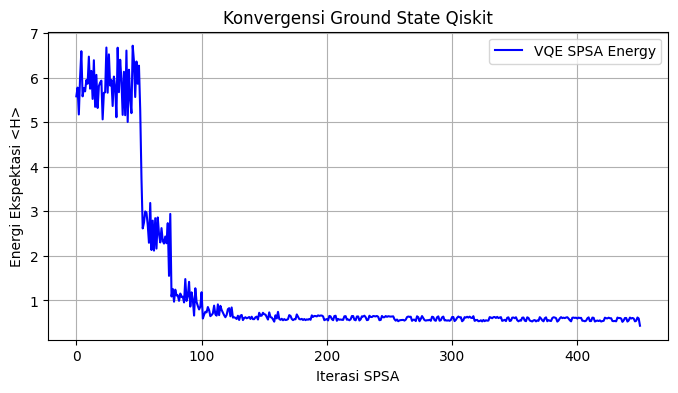

In [65]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import SPSA
from qiskit_algorithms import VQE
import numpy as np
import matplotlib.pyplot as plt

print("--- Membangun Sirkuit Hamiltonian VQE Qiskit ---\n")

# 1. Mengumpulkan Hamiltonian terms
pauli_list = []
coeffs_list = []
num_assets = len(tickers)

# A. Field Terms (Bias / h_i)
# H_bias = - h_i * Z_i
for i, ticker in enumerate(tickers):
    avg_h = final_bias[ticker]
    # Representasi vektor string Pauli Z pada indeks ke-i (Little Endian Qiskit: Qubit 0 ada di paling kanan)
    pauli_str = ['I'] * num_assets
    pauli_str[num_assets - 1 - i] = 'Z'
    pauli_list.append("".join(pauli_str))
    coeffs_list.append(-avg_h)  # Negatif karena H = -h * Z

# B. Interaction Terms (Keterikatan / J_ij)
# H_int = - J_ij * Z_i * Z_j
# Note: Karena pasangan iterasi kita kombinasinya acak secara indeks 0-3, kita deteksi letaknya.
def get_index(ticker_name):
    return tickers.index(ticker_name)

for pair, J_value in interaction_J.items():
    idx1 = get_index(pair[0])
    idx2 = get_index(pair[1])
    
    pauli_str = ['I'] * num_assets
    pauli_str[num_assets - 1 - idx1] = 'Z'
    pauli_str[num_assets - 1 - idx2] = 'Z'
    pauli_list.append("".join(pauli_str))
    coeffs_list.append(-J_value) # Negatif karena model Ferromagnetik -J * Z_i Z_j
    
# Konstruksi SparsePauliOp
print("\n--- Mengaplikasikan Penalty Constraint (K=2, A=5.0) ---")
A = 5.0
K = 2
# H_C = A * I + (A/2) * sum(Z_i Z_j)
pauli_list.append('I' * num_assets)
coeffs_list.append(A)

for pair in itertools.combinations(range(num_assets), 2):
    pauli_str = ['I'] * num_assets
    pauli_str[num_assets - 1 - pair[0]] = 'Z'
    pauli_str[num_assets - 1 - pair[1]] = 'Z'
    pauli_list.append("".join(pauli_str))
    coeffs_list.append(A / 2)

H_operator = SparsePauliOp(pauli_list, coeffs_list)
# Combine redundant terms (Qiskit's simplify method automatically groups identical Pauli strings)
H_operator = H_operator.simplify()
print("Ising Hamiltonian Operator (Qiskit):")
print(H_operator)

# 2. Ansatz: Efficient SU(2) 
# reps = 1 -> Total layer gerbang adalah 2 Layer Parameter. 
ansatz = EfficientSU2(num_qubits=num_assets, reps=1, entanglement='linear')

# 3. Optimizer: SPSA
optimizer = SPSA(maxiter=200)

# Track Evaluasi Energi
vqe_energies_qiskit = []
def callback(eval_count, parameters, mean, std):
    vqe_energies_qiskit.append(mean)

# 4. Solusi VQE
estimator = Estimator()
vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer, callback=callback)

print("\nMenjalankan Optimasi VQE (SPSA), Harap tunggu...")
result = vqe.compute_minimum_eigenvalue(operator=H_operator)

print("\n--- Hasil Optimasi VQE (Qiskit) ---")
print(f"Ground State Energy: {result.eigenvalue.real:.6f}")

# Mengekstrak probability dominan berdasarkan parameter optimal
optimal_circuit = ansatz.assign_parameters(result.optimal_parameters)
from qiskit.quantum_info import Statevector
final_state = Statevector.from_instruction(optimal_circuit)
probs = final_state.probabilities_dict()

# Mengurutkan probabilitas dari yang tertinggi
sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)
best_bitstring = sorted_probs[0][0]

print(f"\nState Paling Stabil (Optimal Bitstring): |{best_bitstring}> dengan probabilitas {sorted_probs[0][1]*100:.2f}%")
print("Interpretasi (Little Endian - Index 0 ada di Kanan, misal |TLKM ASII TPIA BBCA>):")
for i, bit in enumerate(reversed(best_bitstring)):
    action = "Naik (Uptrend)" if bit == '0' else "Turun (Downtrend)"
    print(f" - {tickers[i]}: {action}")

# Plot Konvergensi
plt.figure(figsize=(8, 4))
plt.plot(vqe_energies_qiskit, label="VQE SPSA Energy", color='blue')
plt.xlabel("Iterasi SPSA")
plt.ylabel("Energi Ekspektasi <H>")
plt.title("Konvergensi Ground State Qiskit")
plt.grid(True)
plt.legend()
plt.show()


### Opsi 2: Implementasi VQE menggunakan PennyLane

Sebagai alternatif yang lebih *machine-learning friendly*, PennyLane memungkinkan kita mendefinisikan sirkuit Kuantum sebagai "*QNode*" layaknya *Layer Neural Network*. Kita membangun *ansatz* serupa (lapisan rotasi $RY, RZ$ dan entanglement $CNOT$) dan mengoptimasinya menggunakan PyTorch/Autograd dengan algoritma berbasis gradien (seperti **Adam**) atau optimizer khusus kuantum.


--- Membangun Sirkuit Hamiltonian VQE PennyLane ---


--- Mengaplikasikan Penalty Constraint (K=2, A=5.0) ---
Ising Hamiltonian Operator (PennyLane):
-0.01215322375586052 * Z(0) + -0.018401800691463147 * Z(1) + -0.017347433948682964 * Z(2) + -0.01780076927132636 * Z(3) + 2.450040916260148 * (Z(0) @ Z(1)) + 2.3733636432857645 * (Z(0) @ Z(2)) + 2.3426555125430806 * (Z(0) @ Z(3)) + 2.31943407640517 * (Z(1) @ Z(2)) + 2.155377586709946 * (Z(1) @ Z(3)) + 2.2281332613321725 * (Z(2) @ Z(3)) + 5.0 * I([0, 1, 2, 3])

Menjalankan Optimasi VQE (Adam), Harap tunggu...

--- Hasil Optimasi VQE (PennyLane) ---
Ground State Energy: 0.195236

State Paling Stabil (Optimal Bitstring): |0101> dengan probabilitas 99.99%
Interpretasi (Big Endian - Kebalikan Qiskit, urutan |BBCA TPIA ASII TLKM>):
 - BBCA.JK: Naik (Uptrend)
 - TPIA.JK: Turun (Downtrend)
 - ASII.JK: Naik (Uptrend)
 - TLKM.JK: Turun (Downtrend)


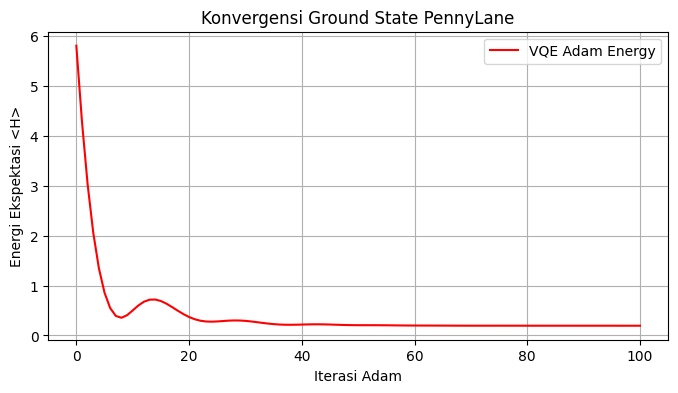

In [66]:
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt

print("--- Membangun Sirkuit Hamiltonian VQE PennyLane ---\n")

num_qubits = len(tickers)

# 1. Definisi Observable Hamiltonian
coeffs = []
obs = []

# A. Field Terms (-h Z_i)
for i, ticker in enumerate(tickers):
    avg_h = final_bias[ticker]
    coeffs.append(-avg_h)
    obs.append(qml.PauliZ(i))

# B. Interaction Terms (-J Z_i Z_j)
def get_index(ticker_name):
    return tickers.index(ticker_name)

for pair, J_value in interaction_J.items():
    idx1 = get_index(pair[0])
    idx2 = get_index(pair[1])
    coeffs.append(-J_value)
    obs.append(qml.PauliZ(idx1) @ qml.PauliZ(idx2))

# Menyusun Hamiltonian
print("\n--- Mengaplikasikan Penalty Constraint (K=2, A=5.0) ---")
A = 5.0
K = 2
# H_C = A * I + (A/2) * sum(Z_i Z_j)
coeffs.append(A)
obs.append(qml.Identity(0)) # Global phase shift identity

import itertools
for pair in itertools.combinations(range(num_qubits), 2):
    coeffs.append(A / 2)
    obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))

H = qml.Hamiltonian(coeffs, obs)
H = H.simplify()
print("Ising Hamiltonian Operator (PennyLane):")
print(H)

# 2. Definisi Ansatz Hardware Efficient SU(2) Manual
n_layers = 1

def efficient_su2_ansatz(params, wires):
    for i in range(num_qubits):
        qml.RY(params[0, i, 0], wires=wires[i])
        qml.RZ(params[0, i, 1], wires=wires[i])

    for layer in range(n_layers):
        # Entanglement
        for i in range(num_qubits - 1):
            qml.CNOT(wires=[wires[i], wires[i+1]])
            
        # Parameterized Rotations
        for i in range(num_qubits):
            qml.RY(params[layer + 1, i, 0], wires=wires[i])
            qml.RZ(params[layer + 1, i, 1], wires=wires[i])

dev = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev)
def cost_function(params):
    efficient_su2_ansatz(params, wires=range(num_qubits))
    return qml.expval(H)

# 3. Optimasi Menggunakan Gradient Descent (SPSA bisa via SciPy di PennyLane, tapi kita pakai Adam/GD default sini)
np.random.seed(42)
# Shape parameter: (n_layers + 1, num_qubits, 2 rotasi Y dan Z)
initial_params = pnp.random.uniform(0, 2 * pnp.pi, (n_layers + 1, num_qubits, 2), requires_grad=True)

opt = qml.AdamOptimizer(stepsize=0.1)
max_iterations = 100

vqe_energies_pennylane = []
params = initial_params

print("\nMenjalankan Optimasi VQE (Adam), Harap tunggu...")
for n in range(max_iterations):
    params, prev_energy = opt.step_and_cost(cost_function, params)
    vqe_energies_pennylane.append(prev_energy)

final_energy = cost_function(params)
vqe_energies_pennylane.append(final_energy)
print(f"\n--- Hasil Optimasi VQE (PennyLane) ---")
print(f"Ground State Energy: {final_energy:.6f}")

@qml.qnode(dev)
def get_probabilities(params):
    efficient_su2_ansatz(params, wires=range(num_qubits))
    return qml.probs(wires=range(num_qubits))

probs_pennylane = get_probabilities(params)

# Mengurutkan probabilitas state dasar (0-15)
state_list = []
for i, p in enumerate(probs_pennylane):
    bitstring = format(i, f'0{num_qubits}b')
    state_list.append((bitstring, p))

sorted_pls = sorted(state_list, key=lambda x: x[1], reverse=True)
best_bitstring_pl = sorted_pls[0][0]

print(f"\nState Paling Stabil (Optimal Bitstring): |{best_bitstring_pl}> dengan probabilitas {sorted_pls[0][1]*100:.2f}%")
print("Interpretasi (Big Endian - Kebalikan Qiskit, urutan |BBCA TPIA ASII TLKM>):")
for i, bit in enumerate(best_bitstring_pl):
    action = "Naik (Uptrend)" if bit == '0' else "Turun (Downtrend)"
    print(f" - {tickers[i]}: {action}")

# Plot Konvergensi
plt.figure(figsize=(8, 4))
plt.plot(range(max_iterations + 1), vqe_energies_pennylane, label="VQE Adam Energy", color='red')
plt.xlabel("Iterasi Adam")
plt.ylabel("Energi Ekspektasi <H>")
plt.title("Konvergensi Ground State PennyLane")
plt.grid(True)
plt.legend()
plt.show()


### Konstruksi Hamiltonian Constraint (Penalti Jumlah Portofolio)

Dalam dunia nyata, kita tidak mungkin membeli semua saham yang menunjukkan *Uptrend*, melainkan kita terbatas oleh anggaran dana atau regulasi portofolio. Kita bisa memaksa VQE untuk **hanya memilih tepat $K$ aset** (misal $K = 2$) dari keseluruhan $N=4$ aset yang tersedia.

Untuk itu, kita tambahkan satu **Hamiltonian Constraint ($H_C$)** ke dalam sistem energi:
$$ H_C = A \left( \sum_{i=1}^N x_i - K \right)^2 $$
Di mana:

- $A$ adalah Konstanta Penalti yang bernilai besar (misal $A = 5.0$) untuk memastikan *state* yang tidak memenuhi $K=2$ diberi penalti energi sangat tinggi hingga dijauhi oleh VQE.
- $x_i$ adalah biner $\{0, 1\}$ yang menyatakan apakah saham $i$ dipilih atau tidak.
 
**Transformasi Kuantum:**
Pada basis komputasi Pauli-Z, state $|0\rangle$ (Naik/Beli) memiliki nilai eigen $+1$ dan state $|1\rangle$ (Turun/Hindari) memiliki nilai eigen $-1$.

Maka biner $x_i$ didefinisikan sebagai proyektor:
$$ x_i = \frac{1 - \sigma_i^z}{2} $$
  
Jika kita substitusikan $x_i$ ke persamaan constraint untuk $N=4$ dan $K=2$:
$$ \sum_{i=1}^4 x_i - 2 = \sum_{i=1}^4 \left(\frac{1 - \sigma_i^z}{2}\right) - 2 $$

$$ = \left(\frac{4}{2} - \frac{1}{2} \sum_{i=1}^4 \sigma_i^z \right) - 2 = -\frac{1}{2} \sum_{i=1}^4 \sigma_i^z $$
 
Lalu kita kuadratkan sesuai rumusan fungsi $A(\dots)^2$:
$$ H_C = A \left( -\frac{1}{2} \sum_{i=1}^4 \sigma_i^z \right)^2 = \frac{A}{4} \left( \sum_{i=1}^4 \sigma_i^z \right)^2 $$
$$ H_C = \frac{A}{4} \left( \sum_{i=1}^4 (\sigma_i^z)^2 + 2 \sum_{i<j} \sigma_i^z \sigma_j^z \right) $$

Karena dikuadratkan, nilai $(\sigma^z)^2$ di ranah matriks Pauli adalah **Matriks Identitas ($I$)**. Sehingga persamaannya menyusut menjadi:
$$ H_C = \frac{A}{4} \left( 4I + 2 \sum_{i<j} \sigma_i^z \sigma_j^z \right) = A \cdot I + \frac{A}{2} \sum_{i<j} \sigma_i^z \sigma_j^z $$

**Kesimpulan Implikasi:**
Untuk memaksa VQE agar memilih tepat 2 aset, kita tidak perlu repot-repot memodifikasi Bias ($h_i$), tapi **cukup menambahkan penalti sebesar $\frac{A}{2}$ ke setiap bobot Interaksi ($J_{ij}$)** antar kedua aset, ditambah satu konstanta energi dasar $A \cdot I$.

### Contoh Kalkulasi Numerik: Siklus VQE (Hamiltonian, Ansatz, SPSA)

Agar lebih intuitif, mari kita bedah secara matematis bagaimana matriks Hamiltonian dibangun secara *under-the-hood* dan dioptimasi oleh VQE. Untuk mempermudah ilustrasi, kita pecah menjadi sub-sistem **2 Qubit** saja, misalnya saham **BBCA (Qubit 0)** dan **ASII (Qubit 1)** dengan konstanta numerik rata-rata yang sudah kita hitung sebelumnya:
- $h_{BBCA} \approx 0.0122$ (Cenderung Naik/Beli)
- $h_{ASII} \approx 0.0173$ (Cenderung Naik/Beli)
- $J_{(BBCA, ASII)} \approx -0.0633$ (Anti-Logis/Interaksi Saling Tarik)

*(Asumsikan belum ada Constraint $K=2$, agar ruang energi tidak bias)*

#### 1. Pembangunan Matriks Hamiltonian ($H$)
Hamiltonian Ising untuk 2 Qubit tersebut didefinisikan sebagai Operator linear:
$$ H = -h_{BBCA} (Z \otimes I) - h_{ASII} (I \otimes Z) - J (Z \otimes Z) $$

Mari kita terjemahkan Operator Pauli-Z ini ke dalam matriks $4 \times 4$ klasikal murni. Operator Pauli-Z bekerja di sumbu diagonal:
- $Z \otimes I = \text{diag}(1, 1, -1, -1)$
- $I \otimes Z = \text{diag}(1, -1, 1, -1)$
- $Z \otimes Z = \text{diag}(1, -1, -1, 1)$

Maka lanskap matriks energi $H$ berpusat di garis diagonal pembacaan basis komputasi *state* $|00\rangle, |01\rangle, |10\rangle, |11\rangle$:
$$ H = \begin{bmatrix} 
(-h_{BBCA} - h_{ASII} - J) & 0 & 0 & 0 \\
0 & (-h_{BBCA} + h_{ASII} + J) & 0 & 0 \\
0 & 0 & (h_{BBCA} - h_{ASII} + J) & 0 \\
0 & 0 & 0 & (h_{BBCA} + h_{ASII} - J)
\end{bmatrix} $$

Substitusikan nilai empiris dari kalkulasi matriks Payoff dan QMI:
- E($|00\rangle$ Beli Semua): $-0.0122 - 0.0173 - (-0.0633) = -0.0295 + 0.0633 = \mathbf{0.0338}$
- E($|01\rangle$ Beli BBCA, Jual ASII): $-0.0122 + 0.0173 - 0.0633 = \mathbf{-0.0582}$
- E($|10\rangle$ Jual BBCA, Beli ASII): $0.0122 - 0.0173 - 0.0633 = \mathbf{-0.0684}$
- E($|11\rangle$ Jual Semua): $0.0122 + 0.0173 + 0.0633 = \mathbf{0.0928}$

**Kesimpulan Matriks Hamiltonian**: Secara fisik tanpa *Constraint*, state yang mematuhi hukum termodinamika energi terendah (*Ground State*) adalah kombinasi $|10\rangle$ bernilai $\mathbf{-0.0684}$, yang mempresentasikan strategi "Hindari BBCA, Beli ASII". (Nilai inilah yang kita ingin agar tertebak 100% oleh Komputer Kuantum saat iterasi berakhir).

#### 2. Pemberian Gerbang Rotasi ($R_y, R_z$) dan Entanglement ($CX$)
VQE tidak membedah matriks diagonal di atas secara klasik, ia melempar tebakan gelombang probabilitas parameterik $|\psi(\vec{\theta})\rangle$ layaknya mesin regresi.
Misal pada iterasi pertama, sirkuit memulai gelombang dari state mutlak $|00\rangle$.
- **Layer Rotasi Tunggal**: 
  - Gerbang $R_y(\theta)$ memutar amplitudo probabilitas, mencampurkan kemungkinan status Beli dan Jual (Superposisi).
    $$ R_y(\theta) |0\rangle = \cos(\theta/2)|0\rangle + \sin(\theta/2)|1\rangle $$
    **Contoh Perhitungan ($\theta = \pi/2$):**
    $$ R_y(\pi/2)|0\rangle = \cos(\pi/4)|0\rangle + \sin(\pi/4)|1\rangle = \frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle $$
    Sehingga probabilitas BBCA menjadi $|1/\sqrt{2}|^2 = 0.5$ (50% Beli, 50% Jual).
  - Gerbang $R_z(\phi)$ menggeser fase relatif antara status $|0\rangle$ dan $|1\rangle$ tanpa mengubah probabilitas besarnya.
    $$ R_z(\phi) (\alpha|0\rangle + \beta|1\rangle) = e^{-i\phi/2}\alpha|0\rangle + e^{i\phi/2}\beta|1\rangle $$
    **Contoh Perhitungan ($\phi = \pi$ pada state superposisi):**
    $$ R_z(\pi) \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \approx \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) $$
    Hal ini memungkinkan VQE mengeksplorasi interferensi fase dalam pencarian energi minimum.
- **Layer Entanglement**: Gerbang *CNOT* ($CX$) menembakkan pulsa antar 2 Qubit. Ia memutar rotasi ASII dari ujung ke ujung jika status BBCA adalah $|1\rangle$. Jika BBCA dan ASII berada di superposisi, CNOT secara instan "mengikat" keterbelitannya (*Entangled*) layaknya benang merah sehingga nasib probabilitas ASII akan bergantung mutlak pada nasib BBCA saat diukur.
    **Contoh Perhitungan (Bell State):**
    Jika BBCA sudah dirotasi ke $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ dan ASII masih $|0\rangle$:
    $$ CX \left( \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes |0\rangle \right) = CX \left( \frac{1}{\sqrt{2}}|00\rangle + \frac{1}{\sqrt{2}}|10\rangle \right) = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) $$
    Kini, jika BBCA diukur sebagai "Beli" ($|0\rangle$), maka ASII otomatis "Beli" ($|0\rangle$). Jika BBCA "Jual" ($|1\rangle$), ASII otomatis "Jual" ($|1\rangle$).

Seluruh tebakan gerbang Ansatz ini (EfficientSU2) menghasilkan vektor tebakan murni $|\psi\rangle$ berukuran $4 \times 1$ berupa probabilitas amplitudo bayangan ($[a_{00}, a_{01}, a_{10}, a_{11}]^T$).

#### 3. Optimasi Menggunakan SPSA (Stochastic Perturbation)
Proses pengukuran (*Measurement*) memproyeksikan vektor tebakan kuantum kita kembali ke Matriks Hamiltonian diagonal $H$.
Total Ekspektasi Energi saat ini adalah: $E = \langle \psi(\vec{\theta}) | H | \psi(\vec{\theta}) \rangle = |a_{00}|^2 E_{00} + |a_{01}|^2 E_{01} + |a_{10}|^2 E_{10} + |a_{11}|^2 E_{11}$.

Selanjutnya, *optimizer* SPSA (klasik) menggeser derajat pintu gerbang $R_y$/$R_z$ untuk iterasi selanjutnya:
1. Hitung energi plus & minus: SPSA membangkitkan vektor perturbasi acak $\Delta$ (misal $\pm 0.1$ derajat) lalu menjalankan sirkuit lagi pada tebakan maju $E(\theta + \Delta)$ dan tebakan mundur $E(\theta - \Delta)$.
2. Estimasi pseudo-Gradien (kelandaian energi): Menarik garis lereng dengan rumus $\frac{E_+ - E_-}{2\Delta}$. (Apakah tebakan maju membuat energinya lebih naik atau makin negatif?)
3. *Update Rule*: SPSA memperbarui sudut gerbang mengikuti arah gradien: $\theta_{\text{baru}} = \theta_{\text{lama}} - \text{learning\_step} \times \text{Gradien}$.

Siklus ini diputar ribuan kali hingga kombinasi sudut tembakan gerbang berhasil menggiring hampir $\approx 100\%$ nilai probabilitas amplitudo jatuh serentak ke dasar diagonal Target, yakni jatuh ke $a_{10}^2 \approx 1.0$ (Membeli ASII). 

Itulah esensi *Variational Quantum Eigensolver* (VQE)!

Starting Setup for Backtesting (2021-2023)...
Data Berhasil Diunduh. Total hari observasi: 813

--- Memulai Backtest dari 2021-01-04 hingga 2023-12-29 ---
[2021-01-04] VQE Terpilih: ['BBCA.JK', 'TPIA.JK']
[2021-02-02] VQE Terpilih: ['BBCA.JK', 'TPIA.JK']
[2021-03-04] VQE Terpilih: ['BBCA.JK', 'TPIA.JK']
[2021-04-06] VQE Terpilih: ['BBCA.JK', 'TPIA.JK']
[2021-05-05] VQE Terpilih: ['BBCA.JK', 'TLKM.JK']
[2021-06-10] VQE Terpilih: ['ASII.JK', 'TLKM.JK']
[2021-07-09] VQE Terpilih: ['BBCA.JK', 'TLKM.JK']
[2021-08-10] VQE Terpilih: ['BBCA.JK', 'TLKM.JK']
[2021-09-10] VQE Terpilih: ['BBCA.JK', 'TLKM.JK']
[2021-10-11] VQE Terpilih: ['BBCA.JK', 'TPIA.JK']
[2021-11-10] VQE Terpilih: ['BBCA.JK', 'TPIA.JK']
[2021-12-09] VQE Terpilih: ['BBCA.JK', 'TLKM.JK']
[2022-01-10] VQE Terpilih: ['BBCA.JK', 'TPIA.JK']
[2022-02-09] VQE Terpilih: ['BBCA.JK', 'TPIA.JK']
[2022-03-14] VQE Terpilih: ['BBCA.JK', 'TPIA.JK']
[2022-04-12] VQE Terpilih: ['BBCA.JK', 'TPIA.JK']
[2022-05-23] VQE Terpilih: ['BBCA.JK', 'TPIA.

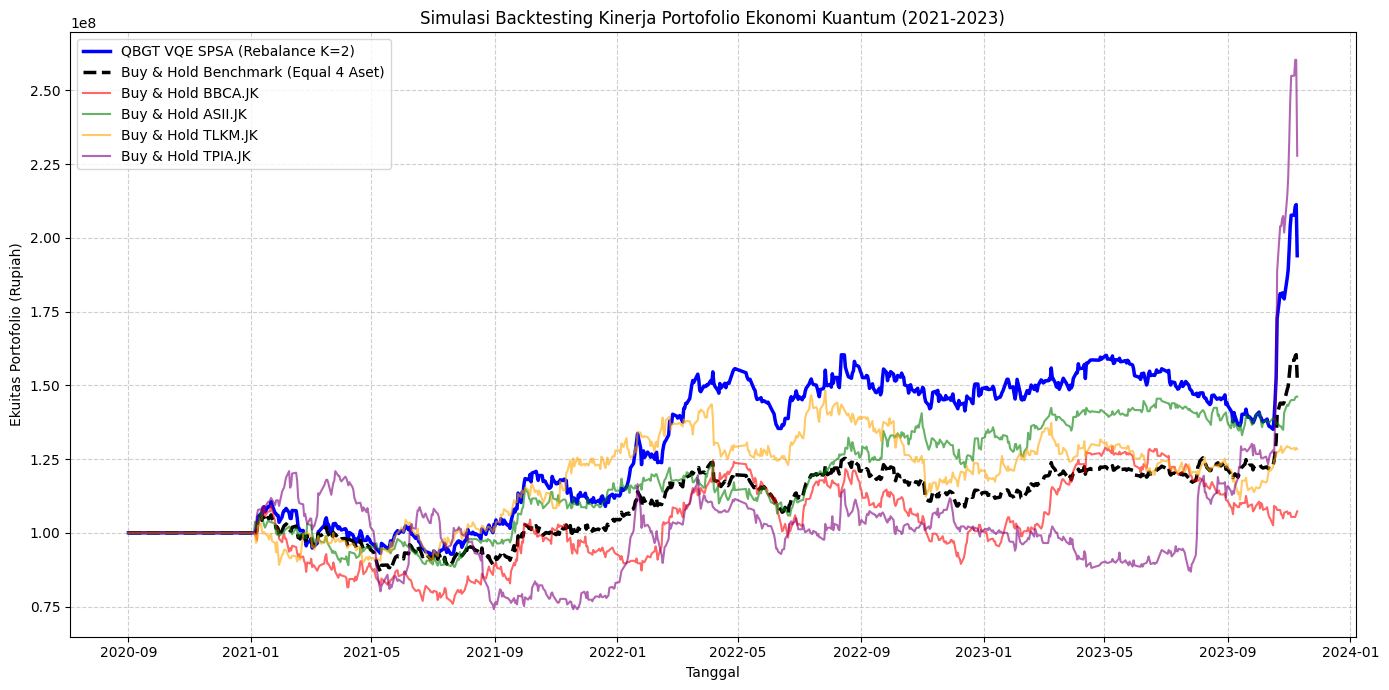

In [73]:
# === Backtesting Engine: 2021 - 2023 (Monthly Rebalance, 3-Month Rolling Window) ===

import yfinance as yf
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt
from itertools import combinations
import warnings

warnings.filterwarnings('ignore')

print("Starting Setup for Backtesting (2021-2023)...")

# 1. Konfigurasi
tickers = ['BBCA.JK', 'ASII.JK', 'TLKM.JK', 'TPIA.JK']
K = 2
penalty_A = 5.0
depth = 1  # Kedalaman Ansatz EfficientSU2
maxiter = 100 # Iterasi SPSA

# Parameter Kalender
initial_capital = 100_000_000.0
# Di bursa, 1 bulan ~ 21 hari perdagangan, 3 bulan ~ 63 hari perdagangan
lookback_days = 63 
rebalance_days = 21 

# 2. Download Data
data = yf.download(tickers, start="2020-09-01", end="2024-01-01", progress=False)['Close']
data = data.dropna()
data_clean = data.sort_index()

print(f"Data Berhasil Diunduh. Total hari observasi: {len(data_clean)}")

# Helper Function: Extract QMI, Bias, Payoffs, and Build Hamiltonian (mirip cell sebelumnya)
def compute_endogenous_lambda(log_returns, tickers):
    mu_annual = log_returns[tickers].mean() * 252
    sigma_annual = log_returns[tickers].std() * np.sqrt(252)
    mu_avg = abs(mu_annual).mean()
    sigma_avg = sigma_annual.mean()
    if np.isnan(mu_avg) or np.isnan(sigma_avg) or (mu_avg + sigma_avg) == 0:
        return 0.5 
    # Sigmoid / Logistic function based on Sharpe Ratio
    Z = mu_avg / sigma_avg
    return 1.0 / (1.0 + np.exp(Z))

def build_hamiltonian(h, J, n_assets, K=2, penalty_A=5.0):
    coeffs = []
    obs = []
    
    # H_cost
    for i in range(n_assets):
        if abs(h[i]) > 1e-10:
            coeffs.append(float(h[i]))
            obs.append(qml.PauliZ(i))
            
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            if abs(J[i, j]) > 1e-10:
                coeffs.append(float(J[i, j]))
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
                
    # H_constraint (Penalty to ensure exactly K assets are chosen)
    coeffs.append(float(penalty_A))
    obs.append(qml.Identity(0)) 
    
    for pair in combinations(range(n_assets), 2):
        coeffs.append(float(penalty_A / 2))
        obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
        
    return qml.Hamiltonian(coeffs, obs)

def run_vqe_spsa_pennylane(H, n_qubits, K=2, depth=1, maxiter=100, seed=42):
    # Gunakan device statik tanpa tembakan untuk optimasi kecepatan
    dev = qml.device("default.qubit", wires=n_qubits)
    
    @qml.qnode(dev)
    def cost_circuit(params):
        weights = params.reshape((depth + 1, n_qubits, 2))
        for layer in range(depth + 1):
            for q in range(n_qubits):
                qml.RY(weights[layer, q, 0], wires=q)
                qml.RZ(weights[layer, q, 1], wires=q)
            if layer < depth:
                for q in range(n_qubits - 1):
                    qml.CNOT(wires=[q, q + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
        return qml.expval(H)

    rng = np.random.default_rng(seed)
    n_params = n_qubits * 2 * (depth + 1)
    params = rng.uniform(0, 2 * np.pi, n_params)
    
    # SPSA Configuration manual update
    a = 0.1 
    c = 0.1
    A = maxiter * 0.1
    alpha = 0.602
    gamma = 0.101
    
    for k in range(maxiter):
        a_k = a / (A + k + 1) ** alpha
        c_k = c / (k + 1) ** gamma
        delta = 2 * rng.integers(0, 2, size=n_params) - 1
        
        cost_plus = float(cost_circuit(params + c_k * delta))
        cost_minus = float(cost_circuit(params - c_k * delta))
        grad = (cost_plus - cost_minus) / (2 * c_k * delta)
        params = params - a_k * grad

    # Penarikan bitstring dari hasil amplitudo
    @qml.qnode(dev)
    def prob_circuit(params):
        weights = params.reshape((depth + 1, n_qubits, 2))
        for layer in range(depth + 1):
            for q in range(n_qubits):
                qml.RY(weights[layer, q, 0], wires=q)
                qml.RZ(weights[layer, q, 1], wires=q)
            if layer < depth:
                for q in range(n_qubits - 1):
                    qml.CNOT(wires=[q, q + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
        return qml.probs(wires=range(n_qubits))

    probs = prob_circuit(params)
    
    # Pilih kombinasi K aset dengan probabilitas tertinggi 
    sorted_indices = np.argsort(probs)[::-1]
    best_bitstring = None
    for idx in sorted_indices:
        bs = format(idx, f'0{n_qubits}b')
        if bs.count('1') == K:
            best_bitstring = bs
            break
            
    if best_bitstring is None:
        best_bitstring = "0011" # Fallback if SPSA gets highly trapped
        
    # Translate bitstring ('1' artinya dipilih, karena Penalty constraint Z Z mencari eigen -1/-1)
    selected_indices = [i for i, bit in enumerate(best_bitstring) if bit == '1']
    return selected_indices

def run_strategy_step(lookback_data, tickers, K=2, penalty_A=5.0):
    log_rets = np.log(lookback_data / lookback_data.shift(1)).dropna()
    binary_sts = (log_rets <= 0).astype(int)
    
    lam = compute_endogenous_lambda(log_rets, tickers)
    
    # Payoffs & Bias h_i
    all_payoffs = {}
    pairs = list(combinations(range(len(tickers)), 2))
    
    # Re-implementasi lokal fungsi payoff & QMI untuk menghindari state luar sel
    def calc_payoff(ret_A, ret_B, st_A, st_B, lam):
        pA, pB, counts = np.zeros((2, 2)), np.zeros((2, 2)), np.zeros((2, 2))
        for t in range(len(st_A)):
            i, j = int(st_A[t]), int(st_B[t])
            counts[i, j] += 1
            u_A = (1 - lam) * (ret_A[t] * 252) - lam * abs(ret_A[t] * 252)
            u_B = (1 - lam) * (ret_B[t] * 252) - lam * abs(ret_B[t] * 252)
            pA[i, j] += u_A
            pB[i, j] += u_B
        for i in range(2):
            for j in range(2):
                if counts[i, j] > 0:
                    pA[i, j] /= counts[i, j]
                    pB[i, j] /= counts[i, j]
        return pA, pB
        
    for idx_a, idx_b in pairs:
        a, b = tickers[idx_a], tickers[idx_b]
        pA, pB = calc_payoff(log_rets[a].values, log_rets[b].values, 
                             binary_sts[a].values, binary_sts[b].values, lam)
        all_payoffs[(idx_a, idx_b)] = (pA, pB)
        
    n_assets = len(tickers)
    h = np.zeros(n_assets)
    for i in range(n_assets):
        payoff_sum, count = 0, 0
        for (a, b), (pA, pB) in all_payoffs.items():
            if a == i:
                payoff_sum += (pA[1, 0] + pA[1, 1]) - (pA[0, 0] + pA[0, 1])
                count += 1
            elif b == i:
                payoff_sum += (pB[0, 1] + pB[1, 1]) - (pB[0, 0] + pB[1, 0])
                count += 1
        if count > 0: h[i] = payoff_sum / count

    # Hitung J_ij via QMI
    J = np.zeros((len(tickers), len(tickers)))
    def calc_qmi(st_A, st_B):
        n_ij = np.zeros((2, 2))
        for t in range(len(st_A)):
            n_ij[int(st_A[t]), int(st_B[t])] += 1
        prob_joint = (n_ij + 1.0) / (len(st_A) + 4.0)
        rho_LF = np.diag(prob_joint.flatten())
        rho_L = np.diag(prob_joint.sum(axis=1))
        rho_F = np.diag(prob_joint.sum(axis=0))
        def svn(rho):
            eig = np.real(la.eigvalsh(rho))
            eig = eig[eig > 1e-12]
            return -np.sum(eig * np.log(eig))
        return svn(rho_L) + svn(rho_F) - svn(rho_LF)

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            qmi = calc_qmi(binary_sts[tickers[i]].values, binary_sts[tickers[j]].values)
            J[i, j] = qmi
            J[j, i] = qmi

    # Susun Hamiltonian & Optimasi
    H = build_hamiltonian(h, J, n_assets, K, penalty_A)
    selected_indices = run_vqe_spsa_pennylane(H, n_assets, K, depth, maxiter)
    
    return selected_indices

# === MAIN BACKTEST LOOP ===
# Filter start data untuk memastikan kita mulai observasi (rebalancing) pada Januari 2021
# Kita cari indeks di data_clean terdekat dengan awal Jan 2021
start_bt_date = pd.to_datetime('2021-01-04')
start_idx = np.searchsorted(data_clean.index, start_bt_date)

rebalance_indices = range(start_idx, len(data_clean), rebalance_days)

# Tracking Array
value_vqe = [initial_capital] * start_idx
value_bench = [initial_capital] * start_idx
value_assets = {t: [initial_capital] * start_idx for t in tickers}

holdings_vqe, holdings_bench = np.zeros(len(tickers)), np.zeros(len(tickers))
cash_vqe, cash_bench = initial_capital, initial_capital
cash_assets = {t: initial_capital for t in tickers}
holdings_assets = {t: 0.0 for t in tickers}

print(f"\n--- Memulai Backtest dari {data_clean.index[start_idx].date()} hingga {data_clean.index[-1].date()} ---")

for i, curr_idx in enumerate(rebalance_indices):
    curr_date = data_clean.index[curr_idx]
    train_start_idx = max(0, curr_idx - lookback_days)
    train_data = data_clean.iloc[train_start_idx:curr_idx]
    
    next_idx = rebalance_indices[i+1] if i+1 < len(rebalance_indices) else len(data_clean)
    
    # 1. Alokasi Portofolio VQE
    selected_indices = run_strategy_step(train_data, tickers, K=K)
    print(f"[{curr_date.date()}] VQE Terpilih: {[tickers[idx] for idx in selected_indices]}")
    
    target_w_vqe = np.zeros(len(tickers))
    if len(selected_indices) > 0:
        weight = 1.0 / len(selected_indices)
        for idx in selected_indices:
            target_w_vqe[idx] = weight
            
    # Alokasi Buy & Hold Equal (Benchmark ke 4 aset)
    target_w_bench = np.full(len(tickers), 1.0 / len(tickers))
    
    # 2. Fungsi Eksekusi Rebalance Bebas Biaya Transaksi (Atau bisa ditambahkan)
    current_prices = data_clean.iloc[curr_idx].values
    def rebalance_portfolio(current_cash, current_holdings, target_weights, prices):
        total_value = current_cash + np.sum(current_holdings * prices)
        target_values = total_value * target_weights
        
        new_holdings = current_holdings.copy()
        new_cash = current_cash
        
        # Jual aset berlebih
        for j in range(len(tickers)):
            c_val = current_holdings[j] * prices[j]
            if c_val > target_values[j]:
                sell_val = c_val - target_values[j]
                shares_sold = sell_val / prices[j]
                new_cash += sell_val
                new_holdings[j] -= shares_sold
        
        # Beli menggunakan cash
        for j in range(len(tickers)):
            c_val = new_holdings[j] * prices[j]
            if c_val < target_values[j]:
                buy_val = target_values[j] - c_val
                if new_cash < buy_val: buy_val = new_cash
                shares_bought = buy_val / prices[j]
                new_cash -= buy_val
                new_holdings[j] += shares_bought
                
        return new_cash, new_holdings

    # Eksekusi VQE dan Benchmark
    cash_vqe, holdings_vqe = rebalance_portfolio(cash_vqe, holdings_vqe, target_w_vqe, current_prices)
    # Buy & Hold benchmark All Asset dieksekusi sekali di awal indeks saja
    if i == 0:
        cash_bench, holdings_bench = rebalance_portfolio(cash_bench, holdings_bench, target_w_bench, current_prices)
    
    # Eksekusi Single Assets
    if i == 0:
        for j, t in enumerate(tickers):
            target_w_indiv = np.zeros(len(tickers))
            target_w_indiv[j] = 1.0
            c_t, h_t = rebalance_portfolio(cash_assets[t], np.zeros(len(tickers)), target_w_indiv, current_prices)
            cash_assets[t] = c_t
            holdings_assets[t] = h_t[j]

    # 3. Trajectory / Mark to Market
    start_d = curr_idx if i == 0 else curr_idx + 1
    for d in range(start_d, next_idx):
        prices = data_clean.iloc[d].values
        
        value_vqe.append(cash_vqe + np.sum(holdings_vqe * prices))
        value_bench.append(cash_bench + np.sum(holdings_bench * prices))
        
        for j, t in enumerate(tickers):
            value_assets[t].append(cash_assets[t] + holdings_assets[t] * prices[j])

print("Backtesting Selesai.")

# === VISUALISASI PERTUMBUHAN PORTOFOLIO ===
plt.figure(figsize=(14, 7))

# Plot VQE Strategy
plt.plot(data_clean.index[:len(value_vqe)], value_vqe, label='QBGT VQE SPSA (Rebalance K=2)', linewidth=2.5, color='blue')

# Plot Buy & Hold All Equal Weights
plt.plot(data_clean.index[:len(value_bench)], value_bench, label='Buy & Hold Benchmark (Equal 4 Aset)', linewidth=2.5, color='black', linestyle='--')

# Plot Individual Buy & Hold
colors = ['red', 'green', 'orange', 'purple']
for j, t in enumerate(tickers):
    plt.plot(data_clean.index[:len(value_assets[t])], value_assets[t], label=f'Buy & Hold {t}', color=colors[j], alpha=0.6)

plt.title('Simulasi Backtesting Kinerja Portofolio Ekonomi Kuantum (2021-2023)')
plt.ylabel('Ekuitas Portofolio (Rupiah)')
plt.xlabel('Tanggal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
